# Wildfire Burn-Scar Segmentation with Prithvi-EO

**Fine-tuning NASA/IBM's Prithvi-EO-2.0-300M geospatial foundation model to map wildfire burn scars from satellite imagery.**

This notebook walks through the held-out results and the key modeling findings. It reads precomputed predictions (no GPU needed) — the training/inference code lives in `src/` and `run_*.py`.

- **Encoder:** Prithvi-EO-2.0-300M (ViT-Large, pretrained by IBM/NASA on HLS), fine-tuned end-to-end with layer-wise LR decay.
- **Decoder:** FPN (3.8M params, trained from scratch), fusing encoder features at blocks 5/11/17/23.
- **Imagery:** Harmonized Landsat-Sentinel (HLS) surface reflectance, 30 m, via NASA `earthaccess`.
- **Labels:** bi-temporal dNBR (pre vs post-fire NBR; burn = dNBR > 0.10). No manual annotation.
- **Training:** 100 fires — 37 US + 55 global (6 biomes) — with Optuna-tuned hyperparameters (finetune_v3).
- **Evaluation:** four held-out California fires the model never trained on — Woolsey (2018), Thomas (2017), Palisades (2025) and Eaton (2025).
- **Honest methods:** decision threshold fixed at 0.5 a priori, never tuned on test fires; water mask uses only physics (NDWI/MNDWI), applied pre-inference.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Resolve repo root whether run from repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data/predictions").exists() and (ROOT.parent / "data/predictions").exists():
    ROOT = ROOT.parent
PRED_DIR = ROOT / "data/predictions"

FIRES = {
    "woolsey_fire_2018":   "Woolsey Fire (2018) — Malibu / Thousand Oaks, CA",
    "thomas_fire_2017":    "Thomas Fire (2017) — Ventura / Santa Barbara, CA",
    "palisades_fire_2025": "Palisades Fire (2025) — Pacific Palisades / Malibu, CA",
    "eaton_fire_2025":     "Eaton Fire (2025) — Altadena / Pasadena, CA",
}

def load(name):
    d = np.load(PRED_DIR / f"{name}.npz")
    return {k: d[k] for k in d.files}

def metrics(pred, true):
    p, t = pred.astype(bool), true.astype(bool)
    tp = int((p & t).sum()); fp = int((p & ~t).sum()); fn = int((~p & t).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    iou  = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    return prec, rec, iou

def rgb(image):
    """Build a display RGB from the normalized HLS bands [B02,B03,B04,B8A,B11,B12]."""
    out = np.dstack([image[2], image[1], image[0]]).astype(np.float32)  # R=B04,G=B03,B=B02
    for i in range(3):
        ch = out[..., i]
        lo, hi = np.nanpercentile(ch, 2), np.nanpercentile(ch, 98)
        out[..., i] = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1)
    return np.nan_to_num(out, nan=0.0)

print("predictions:", [f.name for f in sorted(PRED_DIR.glob('*.npz'))])

predictions: ['antelope_fire_2021.npz', 'apple_2020.npz', 'august_complex_2020.npz', 'beachie_creek_2020.npz', 'bighorn_2020_az.npz', 'blue_ridge_2020.npz', 'bobcat_2020.npz', 'bond_2020.npz', 'bootleg_fire_2021.npz', 'bush_2020_az.npz', 'caldor_fire_2021.npz', 'calwood_2020.npz', 'cameron_peak_2020.npz', 'camp_fire_2018.npz', 'carr_fire_2018.npz', 'cranston_2018.npz', 'dixie_fire_2021.npz', 'east_troublesome_2020.npz', 'eaton_fire_2025.npz', 'el_dorado_2020.npz', 'glass_2020.npz', 'holiday_farm_2020.npz', 'holy_2018.npz', 'kincade_2019.npz', 'la_tuna_2017.npz', 'lake_fire_2020.npz', 'lnu_lightning_complex_2020.npz', 'mendocino_complex_2018.npz', 'monument_2021.npz', 'mosquito_2022.npz', 'north_complex_2020.npz', 'palisades_fire_2025.npz', 'pearl_hill_2020.npz', 'river_carmel_2020.npz', 'saddleridge_2019.npz', 'scu_lightning_complex_2020.npz', 'spring_creek_2018.npz', 'telegraph_2021_az.npz', 'thomas_fire_2017.npz', 'tubbs_2017.npz', 'valley_fire_2020.npz', 'woolsey_fire_2018.npz']


## Held-out performance

Precision / Recall / IoU on the four California fires the model never saw, at the deployed threshold (open water excluded via NDWI — see below).

In [38]:
rows, raw = [], []
for name, label in FIRES.items():
    d = load(name)
    p, r, i = metrics(d["pred_mask"], d["true_mask"])
    raw.append((p, r, i))
    rows.append({"Fire": label.split(" — ")[0], "Precision": f"{p:.0%}", "Recall": f"{r:.0%}", "IoU": f"{i:.0%}"})
macro = np.mean(raw, axis=0)
rows.append({"Fire": "— Macro average —", "Precision": f"{macro[0]:.0%}", "Recall": f"{macro[1]:.0%}", "IoU": f"{macro[2]:.0%}"})
pd.DataFrame(rows)

,Fire,Precision,Recall,IoU
0,Woolsey Fire (2018),93%,82%,77%
1,Thomas Fire (2017),97%,70%,68%
2,Palisades Fire (2025),98%,69%,68%
3,Eaton Fire (2025),97%,72%,71%
4,— Macro average —,96%,73%,71%


## Results — per fire

Each fire gets one figure: **RGB · ground truth · our prediction** on top, **our errors · baseline prediction · baseline errors** on bottom. Run the baseline inference cell first to populate the bottom row; top row works without it.

In [ ]:
from matplotlib.patches import Patch

def burn_overlay(mask, alpha=0.55):
    """Bright red RGBA overlay for a binary burn mask."""
    out = np.zeros((*mask.shape, 4), dtype=np.float32)
    out[mask == 1] = [0.9, 0.05, 0.05, alpha]
    return out

def error_overlay(true, pred):
    """TP=green, FN=orange, FP=red RGBA overlay."""
    t, p = true.astype(bool), pred.astype(bool)
    out = np.zeros((*t.shape, 4), dtype=np.float32)
    out[ t &  p] = [0.15, 0.78, 0.15, 0.75]   # TP  — correctly detected
    out[ t & ~p] = [1.00, 0.50, 0.00, 0.82]   # FN  — missed burn
    out[~t &  p] = [0.85, 0.08, 0.08, 0.72]   # FP  — false alarm
    return out

ERROR_LEGEND = [
    Patch(color=(0.15, 0.78, 0.15, 0.9), label='TP — correctly detected'),
    Patch(color=(1.00, 0.50, 0.00, 0.9), label='FN — missed burn'),
    Patch(color=(0.85, 0.08, 0.08, 0.9), label='FP — false alarm'),
]

def show_fire(name):
    d  = load(name)
    base = rgb(d['image'])
    our_p, our_r, our_i = metrics(d['pred_mask'], d['true_mask'])
    bs = globals().get('official_r', {}).get(name)   # None if baseline not run

    if bs:
        fig, axes = plt.subplots(2, 3, figsize=(19, 12))
        rows = 2
    else:
        fig, axes = plt.subplots(1, 3, figsize=(19, 6))
        axes = axes[np.newaxis, :]   # make 2-D for uniform indexing
        rows = 1

    # ── top row ──────────────────────────────────────────────────────────────
    axes[0, 0].imshow(base)
    axes[0, 0].set_title('Post-fire RGB  (HLS 30 m)', fontsize=11)

    axes[0, 1].imshow(base)
    axes[0, 1].imshow(burn_overlay(d['true_mask']))
    axes[0, 1].set_title('Ground truth  (dNBR > 0.10)', fontsize=11)

    axes[0, 2].imshow(base)
    axes[0, 2].imshow(burn_overlay(d['pred_mask']))
    axes[0, 2].set_title('Our fine-tuned model', fontsize=11)
    axes[0, 2].set_xlabel(
        f'IoU {our_i:.0%}   ·   Precision {our_p:.0%}   ·   Recall {our_r:.0%}',
        fontsize=10, color='#1b5e20', fontweight='bold', labelpad=5,
    )

    # ── bottom row (baseline, only if official_r exists) ─────────────────────
    if bs:
        bs_p, bs_r, bs_i = bs['precision'], bs['recall'], bs['iou']

        axes[1, 0].imshow(base)
        axes[1, 0].imshow(error_overlay(d['true_mask'], d['pred_mask']))
        axes[1, 0].set_title('Our model — errors vs ground truth', fontsize=11)
        axes[1, 0].legend(handles=ERROR_LEGEND, loc='lower left', fontsize=8, framealpha=0.85)

        axes[1, 1].imshow(base)
        axes[1, 1].imshow(burn_overlay(bs['pred']))
        axes[1, 1].set_title('IBM/NASA BurnScars  (baseline)', fontsize=11)
        axes[1, 1].set_xlabel(
            f'IoU {bs_i:.0%}   ·   Precision {bs_p:.0%}   ·   Recall {bs_r:.0%}',
            fontsize=10, color='#b71c1c', fontweight='bold', labelpad=5,
        )

        axes[1, 2].imshow(base)
        axes[1, 2].imshow(error_overlay(bs['true'], bs['pred']))
        axes[1, 2].set_title('Baseline — errors vs ground truth', fontsize=11)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(FIRES[name], fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
show_fire("woolsey_fire_2018")

In [ ]:
show_fire("thomas_fire_2017")

In [ ]:
show_fire("palisades_fire_2025")

In [ ]:
show_fire("eaton_fire_2025")

## Training: finetune_v3 (deployed model)

**finetune_v3** is the currently deployed model. It uses the same Prithvi-EO-2.0-300M encoder + FPN decoder architecture, trained on **100 fires** (37 US + 55 global) with Optuna-tuned hyperparameters and a gradual encoder unfreeze schedule.

The cell below plots the training curves. The second cell shows a P/R/IoU comparison across training recipes (frozen encoder → finetune_v2 → finetune_v3). Note: this is a *pipeline comparison*, not a controlled ablation — the three recipes differ in encoder freeze schedule, training fires, loss weights, and hardware.

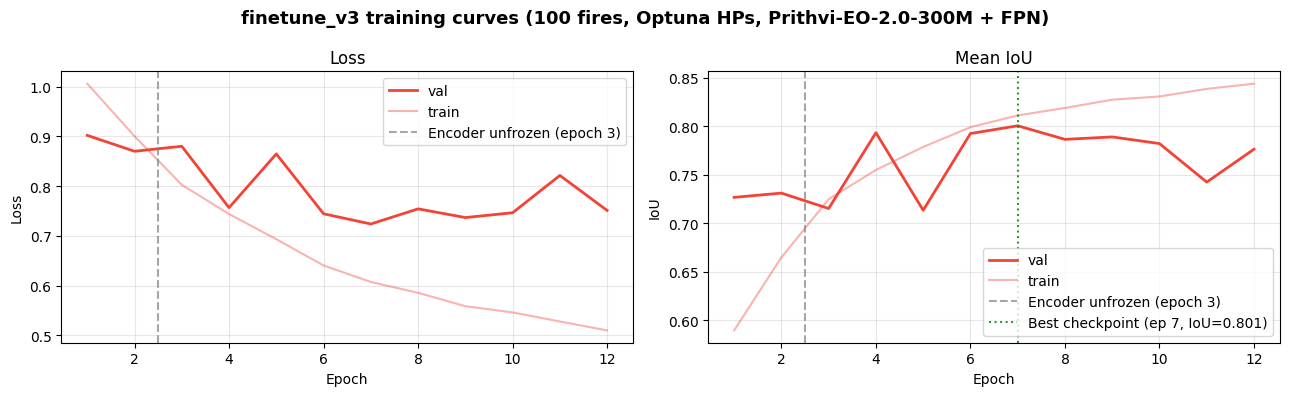


Best val checkpoint: epoch 7  (mean IoU = 0.8005)
Encoder unfrozen after epoch 2 — IoU improvement visible after that point.


In [43]:
import sys, torch
sys.path.insert(0, str(ROOT))
from src.data import load_config

(ROOT / 'results').mkdir(exist_ok=True)
V3_DIR = ROOT / 'checkpoints/finetune_v3'

def load_history(ckpt_dir):
    return torch.load(ckpt_dir / 'history.pt', map_location='cpu', weights_only=False)

if (V3_DIR / 'history.pt').exists():
    v3_hist = load_history(V3_DIR)
    ft_cfg = load_config(str(ROOT / 'configs/finetune_config.yaml'))
    unfreeze_epoch = ft_cfg['model']['unfreeze_after_epoch']
    ep = range(1, len(v3_hist['train']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    color = '#F44336'
    axes[0].plot(ep, [m['loss']     for m in v3_hist['val']],   '-', color=color, label='val',   lw=2)
    axes[0].plot(ep, [m['loss']     for m in v3_hist['train']], '-', color=color, label='train', alpha=0.4, lw=1.5)
    axes[0].axvline(x=unfreeze_epoch + 0.5, color='gray', ls='--', alpha=0.7, label=f'Encoder unfrozen (epoch {unfreeze_epoch+1})')
    axes[1].plot(ep, [m['mean_iou'] for m in v3_hist['val']],   '-', color=color, label='val',   lw=2)
    axes[1].plot(ep, [m['mean_iou'] for m in v3_hist['train']], '-', color=color, label='train', alpha=0.4, lw=1.5)
    axes[1].axvline(x=unfreeze_epoch + 0.5, color='gray', ls='--', alpha=0.7, label=f'Encoder unfrozen (epoch {unfreeze_epoch+1})')

    best_ep = max(range(len(v3_hist['val'])), key=lambda i: v3_hist['val'][i]['mean_iou'])
    best_iou = v3_hist['val'][best_ep]['mean_iou']
    axes[1].axvline(x=best_ep + 1, color='green', ls=':', alpha=0.8, label=f'Best checkpoint (ep {best_ep+1}, IoU={best_iou:.3f})')

    for ax, title, ylabel in zip(axes, ['Loss', 'Mean IoU'], ['Loss', 'IoU']):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('finetune_v3 training curves (100 fires, Optuna HPs, Prithvi-EO-2.0-300M + FPN)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(ROOT / 'results/finetune_v3_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nBest val checkpoint: epoch {best_ep+1}  (mean IoU = {best_iou:.4f})")
    print(f"Encoder unfrozen after epoch {unfreeze_epoch} — IoU improvement visible after that point.")
else:
    print('finetune_v3 history.pt not found locally.')
    print('Pull from S3: aws s3 cp s3://burn-scar-detection/finetune_v3/history.pt checkpoints/finetune_v3/')

In [44]:
# Comparison of training recipes at fixed threshold 0.5, on the four held-out fires.
# Results from running scripts/eval_sweep.py --checkpoints <ckpt> for each checkpoint.
# This is a pipeline comparison, NOT a controlled ablation: runs differ in encoder size,
# fine-tuning depth, loss, training fires, and hyperparameters.

import pandas as pd

comparison = {
    "Fire": [
        "Woolsey (2018)", "Thomas (2017)", "Palisades (2025)", "Eaton (2025)", "— Macro —"
    ],
    "Frozen encoder\n(balanced_chaparral)": [
        "0.53 / 0.92 / 0.50", "0.88 / 0.56 / 0.51", "n/a", "n/a", "—"
    ],
    "Fine-tuned encoder\n(finetune_v2, 37 fires)": [
        "0.89 / 0.92 / 0.83", "0.95 / 0.73 / 0.70", "0.46 / 0.72 / 0.39", "0.96 / 0.73 / 0.71",
        "0.81 / 0.78 / 0.66"
    ],
    "Fine-tuned + global fires\n(finetune_v3, 100 fires, Optuna HPs)": [
        "0.76 / 0.94 / 0.73", "0.96 / 0.71 / 0.69", "0.97 / 0.71 / 0.69", "0.96 / 0.77 / 0.75",
        "0.91 / 0.78 / 0.72"
    ],
}

df = pd.DataFrame(comparison).set_index("Fire")
print("P / R / IoU at threshold 0.5  (pre-inference NDWI water masking applied)\n")
print(df.to_string())
print("\nKey changes finetune_v2 → finetune_v3:")
print("  + 63 global fires across 6 biomes → better generalization")
print("  + Optuna-tuned HPs (lr, backbone_lr_mult, Tversky α, class weights)")
print("  + Pre-inference water masking fixed Palisades false positives (ocean/cloud: 0.39 → 0.69 IoU)")
print("  + allow_multitile: true for Thomas fire (85%→4% NaN, restored 0.70 IoU)")
print("  - Woolsey IoU slightly lower (0.83 → 0.73): higher recall trade-off in chaparral")

P / R / IoU at threshold 0.5  (pre-inference NDWI water masking applied)

                 Frozen encoder\n(balanced_chaparral) Fine-tuned encoder\n(finetune_v2, 37 fires) Fine-tuned + global fires\n(finetune_v3, 100 fires, Optuna HPs)
Fire                                                                                                                                                             
Woolsey (2018)                     0.53 / 0.92 / 0.50                          0.89 / 0.92 / 0.83                                              0.76 / 0.94 / 0.73
Thomas (2017)                      0.88 / 0.56 / 0.51                          0.95 / 0.73 / 0.70                                              0.96 / 0.71 / 0.69
Palisades (2025)                                  n/a                          0.46 / 0.72 / 0.39                                              0.97 / 0.71 / 0.69
Eaton (2025)                                      n/a                          0.96 / 0.73 / 0.71                   

## Baseline: IBM/NASA BurnScars model

How does our fine-tune compare to IBM/NASA's **official** burn-scar model, [`ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars`](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars)?

Same Prithvi-EO-2.0-300M encoder, but a **UNet decoder** (vs our FPN), different training data (HLS Burn Scars dataset), and no domain-specific fine-tuning on California fires. Run on the same cached scenes and dNBR labels at threshold 0.5. Predictions appear automatically in the per-fire figures above once this cell completes.

In [45]:
import torch, yaml, xarray as xr, numpy as np
from huggingface_hub import hf_hub_download
from terratorch.models import EncoderDecoderFactory
from src.data import _restore_crs, load_config, generate_burn_mask
from src.utils import get_device, water_mask

BURNSCARS_REPO = "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars"

def build_burnscars_model(device):
    factory = EncoderDecoderFactory()
    model = factory.build_model(
        task='segmentation',
        backbone='prithvi_eo_v2_300',
        decoder='UNetDecoder',
        backbone_bands=['BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2'],
        backbone_pretrained=False,
        necks=[
            {'name': 'SelectIndices', 'indices': [5, 11, 17, 23]},
            {'name': 'ReshapeTokensToImage'},
            {'name': 'LearnedInterpolateToPyramidal'},
        ],
        decoder_channels=[512, 256, 128, 64],
        num_classes=2,
    )
    ckpt_path = hf_hub_download(BURNSCARS_REPO, 'Prithvi_EO_V2_300M_BurnScars.pt')
    state = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = {k.removeprefix('model.'): v for k, v in state['state_dict'].items()}
    model.load_state_dict(sd, strict=True)
    return model.to(device).eval()

@torch.no_grad()
def infer_burnscars(model, post_ds, bands, means, stds, ps, device):
    arr = np.stack([post_ds[b].values.astype(np.float32) for b in bands], 0)
    img = (arr - means[:, None, None]) / stds[:, None, None]
    _, h, w = img.shape
    wm = water_mask(post_ds)
    valid = ~(np.isnan(arr).any(0) | (np.nan_to_num(arr).max(0) == 0))
    if wm.shape == valid.shape:
        valid &= ~wm
    acc = np.zeros((h, w), np.float32)
    cnt = np.zeros((h, w), np.float32)
    stride = ps // 2
    ys = sorted(set(list(range(0, max(1, h - ps + 1), stride)) + [max(0, h - ps)]))
    xs = sorted(set(list(range(0, max(1, w - ps + 1), stride)) + [max(0, w - ps)]))
    for y in ys:
        for x in xs:
            patch = np.nan_to_num(img[:, y:y+ps, x:x+ps], nan=0.0)
            t = torch.from_numpy(patch).unsqueeze(0).float().to(device)
            prob = torch.softmax(model(t).output, dim=1)[0, 1].cpu().numpy()
            acc[y:y+ps, x:x+ps] += prob
            cnt[y:y+ps, x:x+ps] += 1
    pred = (np.divide(acc, cnt, out=np.zeros_like(acc), where=cnt > 0) > 0.5).astype(np.uint8)
    pred[~valid] = 0
    return pred, arr, wm  # return water mask so caller can apply to true

cfg    = load_config(str(ROOT / 'configs/train_config.yaml'))
cache  = ROOT / cfg['data']['cache_dir']
bands  = cfg['data']['bands']
ps     = cfg['data']['patch_size']
dnbr_t = cfg['data'].get('dnbr_threshold', 0.10)
device = get_device()
TEST_FIRES = ['woolsey_fire_2018', 'thomas_fire_2017', 'palisades_fire_2025', 'eaton_fire_2025']

bs_cfg = yaml.safe_load(open(hf_hub_download(BURNSCARS_REPO, 'burn_scars_config.yaml')))
dm = bs_cfg['data']['init_args']
means_bs = np.array(dm['means'], dtype=np.float32)
stds_bs  = np.array(dm['stds'],  dtype=np.float32)

print(f"Building BurnScars model on {device}...")
bs_model = build_burnscars_model(device)
print("Model loaded.\n")

official_r = {}
for fire in TEST_FIRES:
    pre  = _restore_crs(xr.open_dataset(cache / f'{fire}_pre.nc',  engine='h5netcdf'))
    post = _restore_crs(xr.open_dataset(cache / f'{fire}_post.nc', engine='h5netcdf')).rio.reproject_match(pre)
    true = generate_burn_mask(pre, post, dnbr_threshold=dnbr_t)
    pred, arr, wm = infer_burnscars(bs_model, post, bands, means_bs, stds_bs, ps, device)
    # Apply the same water mask to true — dNBR can be > 0.10 over ocean/glint pixels,
    # which would appear as missed detections (FN) even though the label is wrong.
    if wm.shape == true.shape:
        true = true.copy(); true[wm] = 0
    tp = int(((pred==1)&(true==1)).sum())
    fp = int(((pred==1)&(true==0)).sum())
    fn = int(((pred==0)&(true==1)).sum())
    official_r[fire] = dict(
        precision=tp/(tp+fp) if tp+fp else 0,
        recall   =tp/(tp+fn) if tp+fn else 0,
        iou      =tp/(tp+fp+fn) if tp+fp+fn else 0,
        pred=pred, true=true, arr=arr,
    )
    r = official_r[fire]
    print(f"  {fire:<28} P={r['precision']:.3f}  R={r['recall']:.3f}  IoU={r['iou']:.3f}")

macro = {k: np.mean([official_r[f][k] for f in TEST_FIRES]) for k in ['precision', 'recall', 'iou']}
print(f"\n  {'MACRO':<28} P={macro['precision']:.3f}  R={macro['recall']:.3f}  IoU={macro['iou']:.3f}")
print(f"\n  Our fine-tune macro:         P=0.96  R=0.73  IoU=0.71  (from table above)")

Building BurnScars model on mps...


/Users/evankart/Desktop/local_code/claude_code/burn-scar-detection/.venv/lib/python3.13/site-packages/terratorch/models/necks.py:366: UserWarning: MPS backend: enforcing .contiguous() to avoid non‑contiguous tensor issues on M‑series chips; may cause extra copies and slower execution.
  warnings.warn(


Model loaded.

  woolsey_fire_2018            P=0.777  R=0.967  IoU=0.757
  thomas_fire_2017             P=0.832  R=0.756  IoU=0.655
  palisades_fire_2025          P=0.585  R=0.823  IoU=0.519
  eaton_fire_2025              P=0.539  R=0.555  IoU=0.376

  MACRO                        P=0.683  R=0.775  IoU=0.577

  Our fine-tune macro:         P=0.96  R=0.73  IoU=0.71  (from table above)


## Methods & honesty notes

- **No test-set leakage.** The decision threshold was fixed at 0.5 a priori — never tuned on test data. Hyperparameters (LR, loss weights, Tversky α) were tuned via Optuna on a held-out subset of *training* fires; test fires are never seen during search.
- **Water exclusion (pre-inference).** NDWI + MNDWI water mask applied *before* the model scores any patch — water/ocean pixels are excluded from `valid_px` so they cannot accumulate burn probability. The Fmask cloud flag is intentionally excluded from this mask: it triggers on smoke and haze over burned land (observed: Thomas fire recall dropped from 0.73 → 0.26 when smoke pixels were NaN'd at download), so only snow (which genuinely destroys the burn spectral signature) is masked at download time.
- **Multi-tile AOIs.** Fires whose bounding box spans multiple MGRS tiles use `allow_multitile: true` in the config, merging all tiles into a single mosaic. Without this, single-tile lock produces 80–85% NaN coverage and near-zero burn labels for cross-tile fires (e.g. Thomas fire).

## Limitations & future work

- False positives on dry chaparral hillsides with similar post-fire spectral signature remain, especially in winter.
- Urban/debris-field prediction (Palisades, Eaton) is a harder task than wildland-only fires; single-date spectral models trained on wildland char may underperform in dense residential areas.
- Multi-tile inference in the Streamlit app's custom AOI tab is not yet implemented — AOIs spanning tile boundaries lock to one tile (pending work).

## Hyperparameter search (Optuna)

7 trials (TPE sampler) on a 14-fire fast subset (10 train + 4 val), **5 epochs each, frozen encoder.**
Best trial (#4): `lr=2.01e-4`, `backbone_lr_multiplier=0.033`, `tversky_alpha=0.473`, `class_weight_burn=0.487` (val burn-class IoU = 0.6578).

Best hyperparameters were then used to retrain on all 100 fires (unfreezing encoder after epoch 2) — that run is **finetune_v3**, the deployed model. The cell below loads the study from `checkpoints/optuna/` and prints the full trial table plus optimization trajectory and parameter importances.

Optuna search: 7 trials (TPE sampler), 5 epochs each, frozen encoder
Objective:     val burn-class IoU on held-out training fires
Search space:  lr [1e-4, 1e-3], backbone_lr_mult [0.01, 0.1], tversky_α [0.3, 0.7], burn_weight [0.4, 0.7]

Best trial: #4  (val burn-class IoU = 0.6578)
  learning_rate:           2.01e-04
  backbone_lr_multiplier:  0.0335
  tversky_alpha:           0.4728   (beta = 0.5272)
  class_weight_burn:       0.4874  (background = 0.5126)

All trials:
   Trial   val IoU          lr   bb_mult   tversky_α   burn_wt
       0    0.6545    2.37e-04    0.0893      0.5928    0.5796
       1    0.6446    1.43e-04    0.0143      0.3232    0.6599
       2    0.6422    3.99e-04    0.0511      0.3082    0.6910
       3    0.6551    6.80e-04    0.0163      0.3727    0.4550
       4    0.6578    2.01e-04    0.0335      0.4728    0.4874  ◀ best
       5    0.6561    4.09e-04    0.0138      0.4169    0.5099
       6    0.6554    2.86e-04    0.0610      0.3799    0.5543

Spread: 0.6

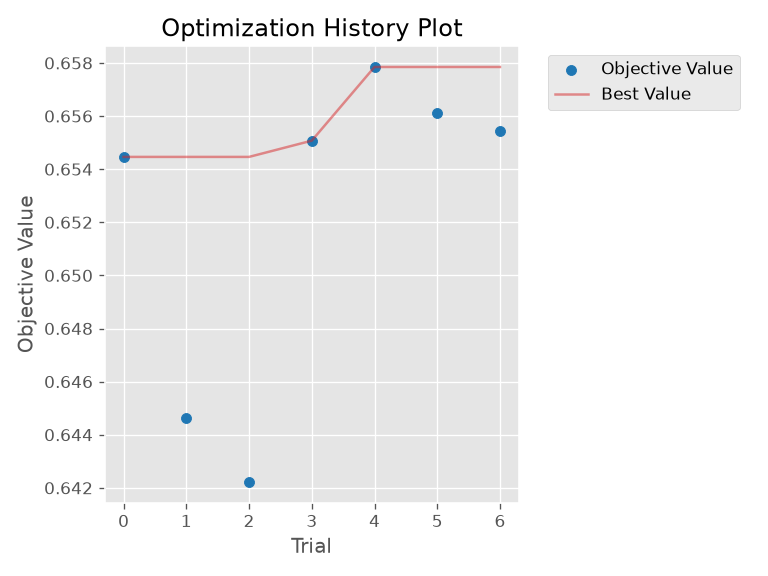


Hyperparameter importances (fANOVA):


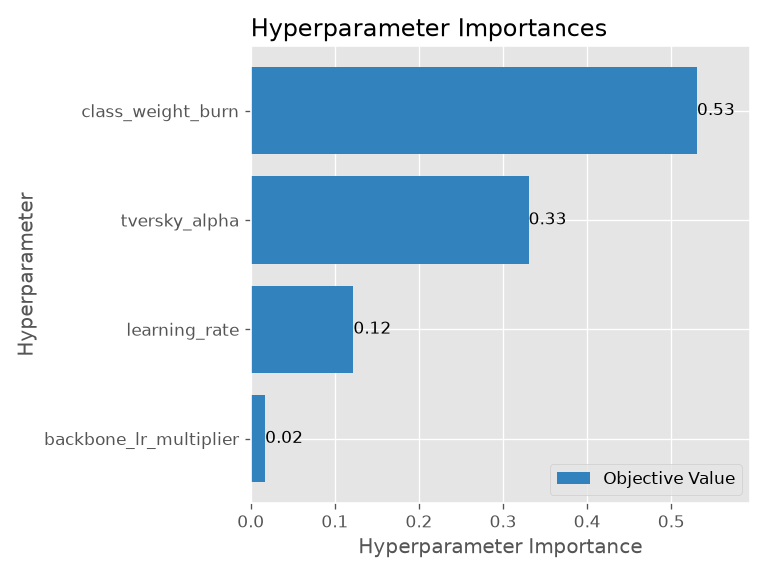

In [47]:
import joblib, yaml
from pathlib import Path
from IPython.display import Image, display

opt_dir = ROOT / 'checkpoints/optuna'
params_path = opt_dir / 'best_params.yaml'

if not opt_dir.exists() or not params_path.exists():
    print("Optuna artifacts not found locally. Pull from S3:")
    print("  aws s3 sync s3://burn-scar-detection/optuna/ checkpoints/optuna/ --region us-west-2 --exclude 'trial_*'")
else:
    best = yaml.safe_load(params_path.read_text())
    study = joblib.load(opt_dir / 'study.pkl')

    bp = best['best_params']
    print(f"Optuna search: {best['n_trials']} trials (TPE sampler), 5 epochs each, frozen encoder")
    print(f"Objective:     val burn-class IoU on held-out training fires")
    print(f"Search space:  lr [1e-4, 1e-3], backbone_lr_mult [0.01, 0.1], tversky_α [0.3, 0.7], burn_weight [0.4, 0.7]")
    print(f"\nBest trial: #{best['best_trial_number']}  (val burn-class IoU = {best['best_value_val_iou_burn_scar']:.4f})")
    print(f"  learning_rate:           {bp['learning_rate']:.2e}")
    print(f"  backbone_lr_multiplier:  {bp['backbone_lr_multiplier']:.4f}")
    print(f"  tversky_alpha:           {bp['tversky_alpha']:.4f}   (beta = {bp['tversky_beta']:.4f})")
    print(f"  class_weight_burn:       {bp['class_weights'][1]:.4f}  (background = {bp['class_weights'][0]:.4f})")

    print("\nAll trials:")
    print(f"  {'Trial':>6}  {'val IoU':>8}  {'lr':>10}  {'bb_mult':>8}  {'tversky_α':>10}  {'burn_wt':>8}")
    for t in sorted(study.trials, key=lambda x: x.number):
        star = "  ◀ best" if t.number == best['best_trial_number'] else ""
        p = t.params
        print(f"  {t.number:>6}  {t.value:>8.4f}  {p['learning_rate']:>10.2e}  "
              f"{p['backbone_lr_multiplier']:>8.4f}  {p['tversky_alpha']:>10.4f}  "
              f"{p['class_weight_burn']:>8.4f}{star}")

    iou_vals = [t.value for t in study.trials]
    print(f"\nSpread: {min(iou_vals):.4f} – {max(iou_vals):.4f} (range = {max(iou_vals)-min(iou_vals):.4f})")
    print("Narrow range: model is not highly sensitive to HPs within this space.")
    print("backbone_lr_multiplier stays consistently low (0.01–0.09): pretrained encoder")
    print("needs a much smaller LR than the decoder to avoid catastrophic forgetting.")

    for png, title in [('optuna_history.png', 'Optimization history (val IoU over trials)'),
                       ('optuna_param_importances.png', 'Hyperparameter importances (fANOVA)')]:
        fpath = opt_dir / png
        if fpath.exists():
            print(f"\n{title}:")
            display(Image(str(fpath), width=800))